<a href="https://colab.research.google.com/github/mmetee/python_2026/blob/main/Tunneling_index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-463/1687506373.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2024-06-01")['Close']
[*********************100%***********************]  1 of 1 completed


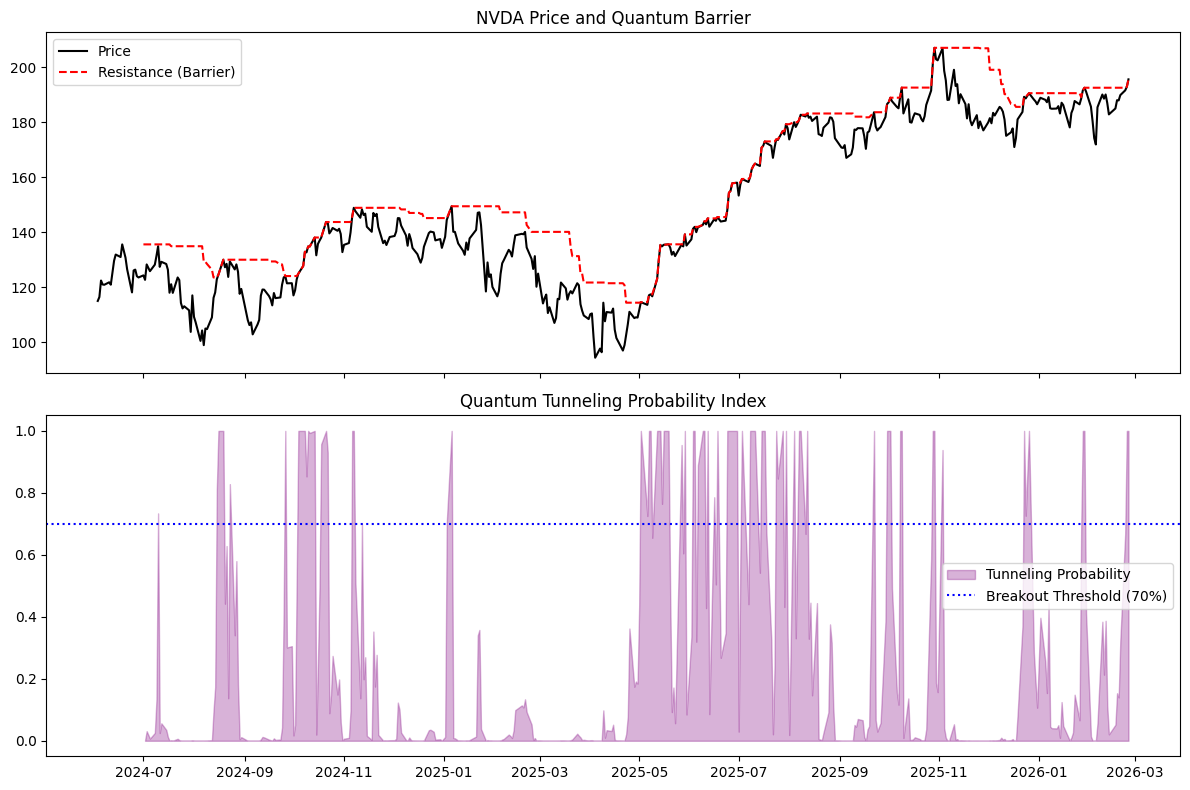

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

def quantum_tunneling_index(ticker):
    # 1. ดึงข้อมูล
    df = yf.download(ticker, start="2024-06-01")['Close']
    # The error indicates `df.values` is producing a 2D array (N, 1) instead of 1D (N,).
    # This might happen if `yf.download(... Ames)['Close']` returns a DataFrame with one column.
    # Flattening ensures `prices` is a 1-dimensional NumPy array.
    prices = df.values.flatten()

    # 2. กำหนด Resistance (V0) - ใช้ Max ในรอบ 20 วันเป็นกำแพง
    # Ensure resistance is 1D
    resistance = pd.Series(prices).rolling(window=20).max().values.flatten()

    # 3. คำนวณค่าพลังงาน (E) และความต่าง (V0 - E)
    # เราใช้ราคาปัจจุบันเป็น E และระยะห่างจาก Resistance เป็นความหนากำแพง
    energy = prices
    barrier_height = resistance - energy

    # 4. คำนวณ Tunneling Probability (T)
    # ยิ่งราคาเข้าใกล้แนวต้าน และติดอยู่นาน (Volatility ต่ำลง) T จะยิ่งสูง
    # Using `df` directly for `pct_change` and `rolling` is appropriate as `df` is the pandas Series.
    # Ensure volatility is 1D
    volatility = df.pct_change().rolling(window=20).std().values.flatten()
    kappa = barrier_height / (volatility * prices + 1e-6)

    # สูตรอย่างง่ายของ T (Exponential Decay ของกำแพง)
    tunneling_prob = np.exp(-2 * kappa)

    # 5. แสดงผล
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(df.index, prices, label='Price', color='black') # Use df.index as x-axis
    ax1.plot(df.index, resistance, label='Resistance (Barrier)', color='red', linestyle='--')
    ax1.set_title(f'{ticker} Price and Quantum Barrier')
    ax1.legend()

    ax2.fill_between(df.index, tunneling_prob, 0, color='purple', alpha=0.3, label='Tunneling Probability')
    ax2.axhline(y=0.7, color='blue', linestyle=':', label='Breakout Threshold (70%)')
    ax2.set_title('Quantum Tunneling Probability Index')
    ax2.legend()

    plt.tight_layout()
    plt.show()

quantum_tunneling_index('NVDA')